# Football Player Value Prediction

This notebook builds a machine learning model to predict football player market value using player attributes.

Pipeline:
1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Feature Engineering
5. Train/Test Split
6. Baseline Models
7. LightGBM Model
8. Model Evaluation
9. Feature Importance
10. Prediction Visualization

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import lightgbm as lgb

## Load Dataset

In [4]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\ProjADYFinal\footballData.csv")
df.head()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club_name,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,33,24/06/1987,170,72,Argentina,FC Barcelona,...,66+3,65+3,65+3,65+3,66+3,62+3,52+3,52+3,52+3,62+3
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,35,5/2/1985,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,54+3,54+3,54+3,61+3
2,200389,https://sofifa.com/player/200389/jan-oblak/210002,J. Oblak,Jan Oblak,27,7/1/1993,188,87,Slovenia,Atlético Madrid,...,32+3,36+3,36+3,36+3,32+3,32+3,33+3,33+3,33+3,32+3
3,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,31,21/08/1988,184,80,Poland,FC Bayern München,...,64+3,65+3,65+3,65+3,64+3,61+3,60+3,60+3,60+3,61+3
4,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,28,5/2/1992,175,68,Brazil,Paris Saint-Germain,...,67+3,62+3,62+3,62+3,67+3,62+3,49+3,49+3,49+3,62+3


## Basic Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18944 entries, 0 to 18943
Columns: 106 entries, sofifa_id to rb
dtypes: float64(18), int64(44), object(44)
memory usage: 15.3+ MB


In [6]:
df.describe()

,sofifa_id,age,height_cm,weight_kg,league_rank,overall,potential,value_eur,wage_eur,international_reputation,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
count,18944.000000,18944.000000,18944.000000,18944.000000,18719.000000,18944.000000,18944.000000,1.894400e+04,18944.000000,18944.000000,...,18944.000000,18944.000000,0.0,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000,18944.000000
mean,226242.402872,25.225823,181.190773,75.016892,1.357070,65.677787,71.086729,2.224813e+06,8675.852513,1.091850,...,48.050412,57.978674,NaN,47.581767,45.546505,16.446052,16.236486,16.103357,16.225982,16.551309
std,27171.091056,4.697354,6.825672,7.057140,0.739327,7.002278,6.109985,5.102486e+06,19654.774894,0.361841,...,15.671721,12.118390,NaN,21.402461,20.953997,17.577332,16.845480,16.519399,17.017341,17.878121
min,41.000000,16.000000,155.000000,50.000000,1.000000,47.000000,47.000000,0.000000e+00,0.000000,1.000000,...,6.000000,12.000000,NaN,5.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,210030.500000,21.000000,176.000000,70.000000,1.000000,61.000000,67.000000,3.000000e+05,1000.000000,1.000000,...,38.750000,50.000000,NaN,27.000000,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,232314.500000,25.000000,181.000000,75.000000,1.000000,66.000000,71.000000,6.500000e+05,3000.000000,1.000000,...,49.000000,59.000000,NaN,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,246760.250000,29.000000,186.000000,80.000000,1.000000,70.000000,75.000000,1.800000e+06,7000.000000,1.000000,...,60.000000,66.000000,NaN,65.000000,63.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,258970.000000,53.000000,206.000000,110.000000,4.000000,93.000000,95.000000,1.055000e+08,560000.000000,5.000000,...,92.000000,96.000000,NaN,93.000000,90.000000,90.000000,92.000000,93.000000,91.000000,90.000000


## Exploratory Data Analysis

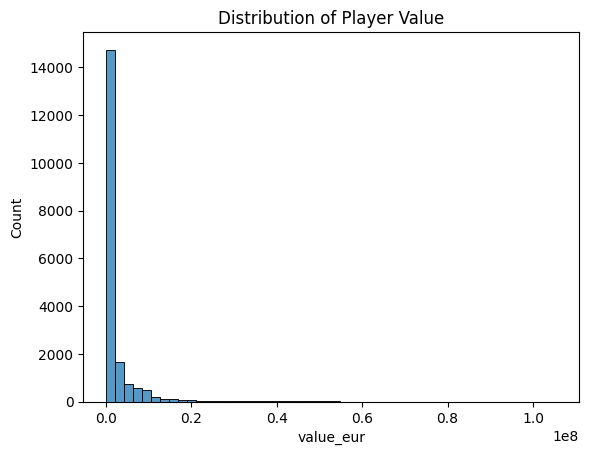

In [7]:
plt.figure()
sns.histplot(df['value_eur'].dropna(), bins=50)
plt.title('Distribution of Player Value')
plt.show()

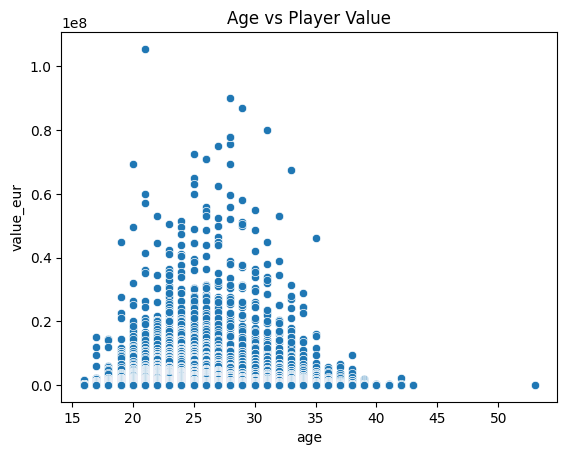

In [8]:
plt.figure()
sns.scatterplot(x=df['age'], y=df['value_eur'])
plt.title('Age vs Player Value')
plt.show()

## Data Preprocessing

In [9]:
df = df.dropna(subset=['value_eur'])

In [10]:
features = ['age','height_cm','weight_kg','overall','potential','pace','shooting','passing','dribbling','defending','physic']

X = df[features]
y = df['value_eur']

## Log Transform Target

In [11]:
y = np.log1p(y)

## Train Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Baseline Model: Linear Regression

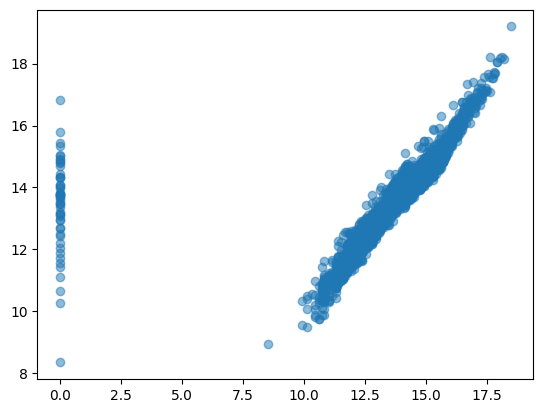

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

# 1. Điền giá trị trung bình vào các chỗ trống (NaN)
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 2. Bây giờ chạy LinearRegression sẽ mượt mà
lr = LinearRegression()
lr.fit(X_train_imputed, y_train)

# 3. Dự đoán
lr_pred = lr.predict(X_test_imputed)

# 4. Vẽ biểu đồ (Lúc này y_test và lr_pred chắc chắn cùng size 3789)
import matplotlib.pyplot as plt
plt.scatter(y_test, lr_pred, alpha=0.5)
plt.show()

## Baseline Model: Random Forest

In [14]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

## LightGBM Model

In [15]:
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6
)

model.fit(X_train, y_train)

lgb_pred = model.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000663 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 630
[LightGBM] [Info] Number of data points in the train set: 15155, number of used features: 11
[LightGBM] [Info] Start training from score 13.379673
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

## Evaluation Function

In [ ]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(name)
    print('RMSE:', rmse)
    print('MAE:', mae)
    print('R2:', r2)
    print()

In [ ]:
evaluate(y_test, lr_pred, 'Linear Regression')
evaluate(y_test, rf_pred, 'Random Forest')
evaluate(y_test, lgb_pred, 'LightGBM')

Linear Regression
RMSE: 1.6165505606421238
MAE: 0.4394419562791511
R2: 0.39524694848452413

Random Forest
RMSE: 1.6367602476021368
MAE: 0.38469656746760217
R2: 0.3800315046269034

LightGBM
RMSE: 1.5980499594137874
MAE: 0.4147205145932658
R2: 0.4090099239677184



## Feature Importance

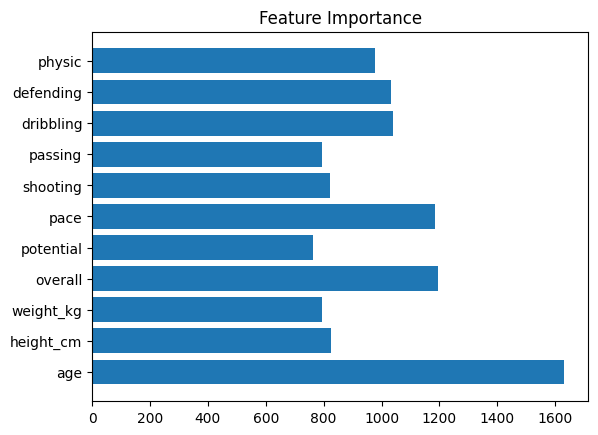

In [ ]:
importance = model.feature_importances_

plt.figure()
plt.barh(features, importance)
plt.title('Feature Importance')
plt.show()

## Prediction vs Actual

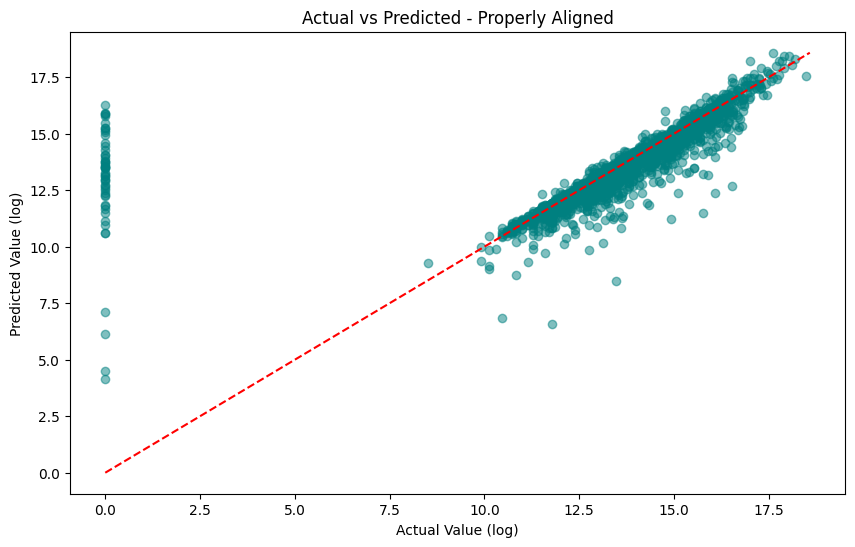

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Lấy đúng giá trị thực tế (y) của những cầu thủ có trong X_test
# Lưu ý: Thay 'Value' bằng tên cột giá trị cầu thủ thực tế trong df của bạn
y_actual = y_test.loc[X_test.index] 

# 2. Vẽ biểu đồ chuẩn   
plt.figure(figsize=(10, 6))
plt.scatter(y_actual, lgb_pred, alpha=0.5, color='teal')

# 3. Vẽ đường chéo y = x (đường dự báo hoàn hảo)
limit = max(y_actual.max(), lgb_pred.max())
plt.plot([y_actual.min(), limit], [y_actual.min(), limit], color='red', linestyle='--')

plt.xlabel('Actual Value (log)')
plt.ylabel('Predicted Value (log)')
plt.title('Actual vs Predicted - Properly Aligned')
plt.show()